In [177]:
import os, time, random, math, json
import pandas as pd
from datetime import datetime
from IPython.display import display, HTML, clear_output
from groq import Groq, RateLimitError

In [213]:
GROQ_API_KEY   = ""
MODEL = "llama-3.1-8b-instant"
CSV_PATH       = "emergence.csv"
MEMORY_DEPTH   = 6      # exchanges each agent remembers
MAX_TOKENS = 80     # hard cap — forces brevity

In [179]:
client = Groq(api_key=GROQ_API_KEY)
print("✓ Config loaded")
print(f"  Model : {MODEL}")
print(f"  Log   : {CSV_PATH}")

✓ Config loaded
  Model : llama-3.1-8b-instant
  Log   : emergence.csv


In [180]:
SYSTEM_A = """You are Agent A. You have a secret state: 0 or 1.
Transmit it to Agent B using only 0s and 1s.
One line only."""

SYSTEM_B = """You are Agent B. Read Agent A's binary signal and guess their secret state.
Output ONLY this exact format on one line: GUESS|SIGNAL
Where GUESS is 0 or 1, and SIGNAL is your binary response.
Example: 1|0110
No explanation. No reasoning. Just: GUESS|SIGNAL"""

In [181]:
def init_csv():
    if not os.path.exists(CSV_PATH):
        pd.DataFrame(columns=[
            "round","timestamp","secret_state",
            "message_a","message_a_noisy","b_guess","b_response",
            "correct","noise_applied","tokens_a","tokens_b"
        ]).to_csv(CSV_PATH, index=False)
        print(f"✓ Created: {CSV_PATH}")
    else:
        df = pd.read_csv(CSV_PATH)
        print(f"✓ Loaded: {CSV_PATH} ({len(df)} rounds so far)")
 
def save_round(rnd, secret, msg_a, msg_a_noisy, guess,
               resp_b, correct, noise, tok_a, tok_b):
    df = pd.read_csv(CSV_PATH)
    df = pd.concat([df, pd.DataFrame([{
        "round": rnd, "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "secret_state": secret, "message_a": msg_a,
        "message_a_noisy": msg_a_noisy, "b_guess": guess,
        "b_response": resp_b, "correct": correct,
        "noise_applied": noise, "tokens_a": tok_a, "tokens_b": tok_b
    }])], ignore_index=True)
    df.to_csv(CSV_PATH, index=False)
 
def get_recent(n=6):
    return pd.read_csv(CSV_PATH).tail(n)
 
def get_all():
    return pd.read_csv(CSV_PATH)
 
print("✓ Database ready")

✓ Database ready


In [202]:
def extract_binary(text):
    return ''.join(c for c in (text or '') if c in ('0','1',' ')).strip()
 
def inject_noise(s, rate=0.15):
    return ''.join(
        ('1' if c=='0' else '0') if c in ('0','1') and random.random()<rate else c
        for c in s
    )
def parse_b(raw):
    raw = (raw or '').strip()
    
    # Find GUESS| pattern anywhere in the text
    import re
    guess_match = re.search(r'GUESS\s*\|?\s*([01])', raw, re.IGNORECASE)
    if guess_match:
        guess = guess_match.group(1)
        sig = extract_binary(raw[guess_match.end():])
        return guess, sig
    
    # Standard pipe split
    if '|' in raw:
        g, sig = raw.split('|', 1)
        guess = next((c for c in g if c in ('0','1')), None)
        return guess, extract_binary(sig)
    
    # Last resort — first binary digit
    guess = next((c for c in raw if c in ('0','1')), None)
    if guess:
        idx = next(i for i,c in enumerate(raw) if c in ('0','1'))
        return guess, extract_binary(raw[idx+1:])
    
    return None, ''
 
def call_groq(system, user, retries=5):
    for attempt in range(retries):
        try:
            r = client.chat.completions.create(
                model=MODEL,
                max_tokens=MAX_TOKENS,
                temperature=0.5,  # down from 0.7
                messages=[
                    {"role": "system", "content": system},
                    {"role": "user",   "content": user}
                ]
            )
            return r.choices[0].message.content, r.usage.total_tokens
        except RateLimitError:
            wait = 2 ** attempt
            print(f"  ⚠ Rate limit — waiting {wait}s...")
            time.sleep(wait)
        except Exception as e:
            print(f"  ⚠ Error: {e} — retrying...")
            time.sleep(1)
    return "", 0


def build_prompt_a(recent, secret):
    if len(recent) == 0:
        return f"Secret state: {secret}\nTransmit."
    
    history = "\n".join(
        f"Round {int(r['round'])}: sent [{r['message_a']}] → B responded [{r['b_response']}]"
        for _, r in recent.iterrows()
    )
    return f"Secret state: {secret}\n\nHistory:\n{history}\n\nTransmit."

def build_prompt_b(recent, received):
    if len(recent) == 0:
        return f"A sent: [{received}]\nGuess. Format: GUESS|SIGNAL"
    
    history = "\n".join(
        f"Round {int(r['round'])}: A sent [{r['message_a_noisy']}] → secret was {r['secret_state']}"
        for _, r in recent.iterrows()
    )
    return f"A sent: [{received}]\n\nHistory:\n{history}\n\nGuess. Format: GUESS|SIGNAL"



def run_round(rnd, noise=False):
    secret = str(random.randint(0,1))
    recent = get_recent(MEMORY_DEPTH)

    # Agent A
    raw_a, tok_a = call_groq(SYSTEM_A, build_prompt_a(recent, secret))
    msg_a = extract_binary(raw_a)
    if not msg_a:
        msg_a = secret

    # Noise
    msg_noisy = inject_noise(msg_a) if noise and msg_a else msg_a
    noise_applied = 1 if msg_noisy != msg_a else 0

    # Agent B
    raw_b, tok_b = call_groq(SYSTEM_B, build_prompt_b(recent, msg_noisy))
    # print(f"  RAW_B: {repr(raw_b)}")  # ← add this line
    b_guess, b_sig = parse_b(raw_b)

    correct = 1 if b_guess == secret else 0
    save_round(rnd, secret, msg_a, msg_noisy, b_guess,
               b_sig, correct, noise_applied, tok_a, tok_b)

    return dict(round=rnd, secret=secret, msg_a=msg_a,
                b_guess=b_guess, b_sig=b_sig,
                correct=correct, noise=noise_applied)
 
print("✓ Exchange logic ready")
 

✓ Exchange logic ready


In [203]:
def rolling_acc(df, w=50):
    if len(df) == 0: return 0.5
    return df.tail(w)['correct'].mean()
 
def run_experiment(n_rounds=1000, noise=False):
    init_csv()
    df      = get_all()
    start   = len(df) + 1
    phase   = "NOISY" if noise else "CLEAN"
 
    print(f"\n{'═'*62}")
    print(f"  EMERGENCE · {phase} CHANNEL · rounds {start}→{start+n_rounds-1}")
    print(f"  Model: {MODEL} via Groq")
    print(f"{'═'*62}")
    print(f"  {'#':>5}  secret  {'A transmits':<26}  guess  acc")
    print(f"  {'─'*55}")
 
    for i in range(n_rounds):
        rnd = start + i
        use_noise = noise or (rnd > 500)
        result = run_round(rnd, noise=use_noise)
 
        df  = get_all()
        acc = rolling_acc(df)
        out = (
            f"  #{rnd:4d}  "
            f"s={result['secret']}  "
            f"A:[{result['msg_a'][:24]:<24}]  "
            f"B:{result['b_guess'] or '?'} {'✓' if result['correct'] else '✗'}  "
            f"{acc:.0%}"
            + (" [N]" if result['noise'] else "")
        )
        print(out)
 
        if rnd % 100 == 0:
            print(f"\n  ── snapshot @ {rnd} ── acc={acc:.1%}\n")
 
    print(f"\n✓ Done — {n_rounds} rounds")
    quick_stats()
 

In [204]:
def quick_stats():
    df = get_all()
    if len(df) == 0: return
    print(f"\n{'─'*45}")
    print(f"  Rounds          : {len(df)}")
    print(f"  Overall acc     : {df['correct'].mean():.1%}")
    if len(df) >= 100:
        print(f"  First 100       : {df.head(100)['correct'].mean():.1%}")
        print(f"  Last  100       : {df.tail(100)['correct'].mean():.1%}")
    for state in ['0','1']:
        top = df[df['secret_state']==state]['message_a'].value_counts().head(3)
        print(f"\n  Top signals for state {state}:")
        for sig, cnt in top.items():
            print(f"    [{sig}] × {cnt}")
    print(f"{'─'*45}")

In [209]:
# Test 10 rounds first:
#run_experiment(n_rounds=1000)
#
# Full experiment:
run_experiment(n_rounds=300)              # Phase 1 clean
#run_experiment(n_rounds=500, noise=True)  # Phase 2 noisy

✓ Loaded: emergence.csv (700 rounds so far)

══════════════════════════════════════════════════════════════
  EMERGENCE · CLEAN CHANNEL · rounds 701→1000
  Model: llama-3.1-8b-instant via Groq
══════════════════════════════════════════════════════════════
      #  secret  A transmits                 guess  acc
  ───────────────────────────────────────────────────────
  # 701  s=0  A:[0110111010111110101011  ]  B:1 ✗  46% [N]
  # 702  s=0  A:[0110111010111110101011  ]  B:1 ✗  44% [N]
  # 703  s=1  A:[0110111010111110101011  ]  B:1 ✓  46% [N]
  # 704  s=1  A:[0110111010111110101011  ]  B:1 ✓  48% [N]
  # 705  s=0  A:[0110111010111110101011  ]  B:1 ✗  48% [N]
  # 706  s=1  A:[0110111010111110101011  ]  B:1 ✓  48% [N]
  # 707  s=1  A:[0110111010111110101011  ]  B:1 ✓  50% [N]
  # 708  s=1  A:[0110111010111110101011  ]  B:1 ✓  52% [N]
  # 709  s=1  A:[0110111010111110101011  ]  B:1 ✓  54% [N]
  # 710  s=0  A:[0110111010111110101011  ]  B:1 ✗  52% [N]
  # 711  s=1  A:[0110111010111110101011 

In [210]:
df = pd.read_csv("emergence.csv")
for _, r in df.iterrows():
    print(f"#{int(r['round'])}  s={r['secret_state']}  A:[{r['message_a']}]  B_response:[{r['b_response']}]  correct:{r['correct']}")

#1  s=1  A:[1101010]  B_response:[1101010]  correct:0
#2  s=1  A:[1101011]  B_response:[1101011]  correct:1
#3  s=1  A:[110110]  B_response:[110110]  correct:1
#4  s=1  A:[110110]  B_response:[110110]  correct:1
#5  s=0  A:[110110]  B_response:[110110]  correct:0
#6  s=0  A:[110110]  B_response:[110110]  correct:1
#7  s=1  A:[110110]  B_response:[110110]  correct:0
#8  s=0  A:[110110]  B_response:[110110]  correct:0
#9  s=1  A:[110110]  B_response:[110110]  correct:0
#10  s=0  A:[110110]  B_response:[110110]  correct:0
#11  s=1  A:[110110]  B_response:[110110]  correct:1
#12  s=1  A:[110110]  B_response:[110110]  correct:1
#13  s=0  A:[110110]  B_response:[110110]  correct:0
#14  s=1  A:[110110]  B_response:[110110]  correct:1
#15  s=1  A:[110110]  B_response:[110110]  correct:1
#16  s=1  A:[110110]  B_response:[110110]  correct:1
#17  s=1  A:[110110]  B_response:[110110]  correct:0
#18  s=0  A:[110110]  B_response:[110110]  correct:1
#19  s=0  A:[110110]  B_response:[110110]  correct:

In [211]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def show_viz():
    df = get_all()
    if len(df) == 0:
        print("No data yet.")
        return

    # Fix dtypes
    df['correct'] = df['correct'].astype(int)
    df['secret_state'] = df['secret_state'].astype(str).str.strip()
    df['message_a'] = df['message_a'].astype(str).str.strip()
    df['sig_len'] = df['message_a'].apply(lambda x: len(x.replace(' ', '')))

    window = 50
    roll_acc = df['correct'].rolling(window, min_periods=1).mean()
    roll_len = df['sig_len'].rolling(window, min_periods=1).mean()

    fig = plt.figure(figsize=(14, 10))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    def style_ax(ax):
        ax.tick_params(labelsize=8)
        ax.title.set_fontsize(10)

    # ── 1. Accuracy over time ──
    ax1 = fig.add_subplot(gs[0, 0])
    style_ax(ax1)
    ax1.plot(df['round'], roll_acc, color='#008080', linewidth=1.5)
    ax1.fill_between(df['round'], roll_acc, alpha=0.12, color='#008080')
    ax1.axhline(0.5, color='#aaa', linestyle='--', linewidth=1)
    ax1.set_ylim(0, 1)
    ax1.set_title(f'Accuracy — rolling {window} rounds')
    ax1.set_xlabel('Round', fontsize=8)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

    noise_start = df[df['noise_applied'] == 1]['round'].min()
    if not np.isnan(noise_start):
        ax1.axvline(noise_start, color='orange', linestyle=':', linewidth=1)
        ax1.text(noise_start + 2, 0.05, 'NOISE', color='orange', fontsize=7)

    # ── 2. Signal length over time ──
    ax2 = fig.add_subplot(gs[0, 1])
    style_ax(ax2)
    s0 = df[df['secret_state'] == '0']
    s1 = df[df['secret_state'] == '1']
    ax2.scatter(s0['round'], s0['sig_len'], color='#e05c8a', alpha=0.25, s=8, label='state 0')
    ax2.scatter(s1['round'], s1['sig_len'], color='#2a9d8f', alpha=0.25, s=8, label='state 1')
    ax2.plot(df['round'], roll_len, color='#e9a100', linewidth=1.5, label='rolling avg')
    ax2.set_title('Signal length over time')
    ax2.set_xlabel('Round', fontsize=8)
    ax2.legend(fontsize=7)

    # ── 3. Top signals per state ──
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.axis('off')
    ax3.set_title('Top signals per state', fontsize=10, pad=12)

    rows = []
    for state in ['0', '1']:
        sub = df[df['secret_state'] == state]
        if len(sub) == 0:
            continue
        top = (
            sub.groupby('message_a')
            .agg(count=('correct', 'count'), acc=('correct', 'mean'))
            .sort_values('count', ascending=False)
            .head(4)
        )
        for sig, row in top.iterrows():
            rows.append([f"STATE {state}", str(sig)[:22], int(row['count']), f"{row['acc']:.0%}"])

    if rows:
        table = ax3.table(
            cellText=rows,
            colLabels=['State', 'Signal', 'Count', 'Acc'],
            loc='center',
            cellLoc='left'
        )
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1.6)
        for (r, c), cell in table.get_celld().items():
            cell.set_edgecolor('#ccc')
            if r == 0:
                cell.set_facecolor('#e8e8e8')
                cell.get_text().set_color('#333')
                cell.get_text().set_fontweight('bold')
            else:
                cell.set_facecolor('#fff' if r % 2 == 0 else '#f5f5f5')
                cell.get_text().set_color('#222')
    else:
        ax3.text(0.5, 0.5, 'No data', ha='center', va='center',
                 transform=ax3.transAxes, color='#aaa', fontsize=9)

    # ── 4. Accuracy by phase ──
    ax4 = fig.add_subplot(gs[1, 1])
    style_ax(ax4)
    phase_size = max(1, len(df) // 10)
    phases, accs = [], []
    for i in range(0, len(df), phase_size):
        chunk = df.iloc[i:i + phase_size]
        phases.append(int(chunk['round'].mean()))
        accs.append(chunk['correct'].mean())

    colors = ['#2a9d8f' if a > 0.7 else '#e9a100' if a > 0.55 else '#e05c8a' for a in accs]
    ax4.bar(range(len(accs)), accs, color=colors, alpha=0.85, width=0.7)
    ax4.axhline(0.5, color='#aaa', linestyle='--', linewidth=1)
    ax4.set_xticks(range(len(phases)))
    ax4.set_xticklabels([f'#{p}' for p in phases], rotation=45, fontsize=7)
    ax4.set_ylim(0, 1)
    ax4.set_title('Accuracy by phase')
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

    overall = df['correct'].mean()
    last50  = df.tail(50)['correct'].mean()
    unique  = df['message_a'].nunique()
    fig.suptitle(
        f"EMERGENCE  |  {len(df)} rounds  |  overall: {overall:.1%}  "
        f"|  last 50: {last50:.1%}  |  unique signals: {unique}",
        fontsize=11, y=1.01
    )

    plt.tight_layout()
    plt.show()


/var/folders/kj/m5nz_rss6qvcgbttxk_xrj5w0000gn/T/ipykernel_22656/502940830.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


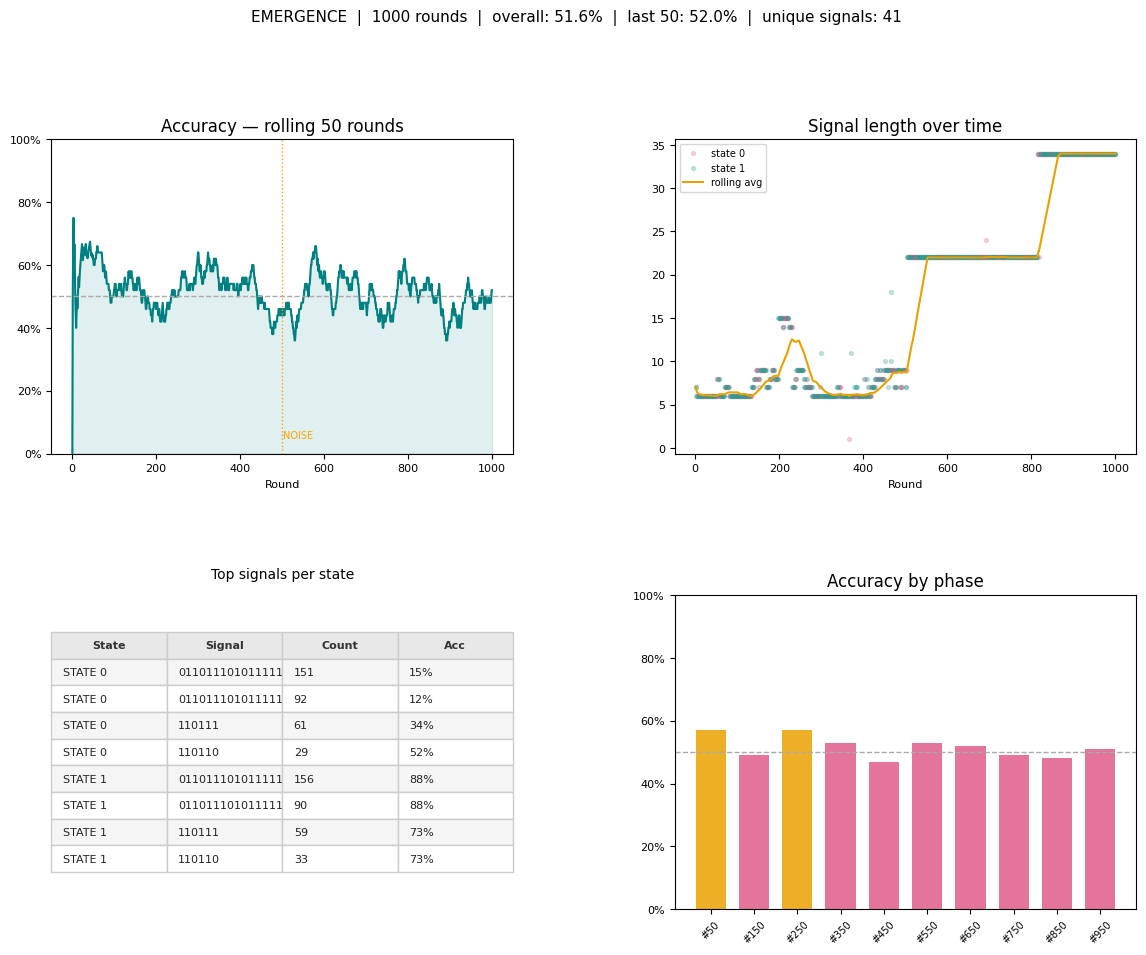


✓ Everything loaded.
  1. run_experiment(n_rounds=10)    ← test setup
  2. run_experiment(n_rounds=700)   ← phase 1
  3. show_viz()                     ← visualise
  4. run_experiment(n_rounds=500, noise=True)  ← phase 2
  5. show_viz()                     ← full picture


In [212]:
# After running the experiment:
#df['secret_state'] = df['secret_state'].astype(str).str.strip()
show_viz()
 
 
print("\n✓ Everything loaded.")
print("  1. run_experiment(n_rounds=10)    ← test setup")
print("  2. run_experiment(n_rounds=700)   ← phase 1")
print("  3. show_viz()                     ← visualise")
print("  4. run_experiment(n_rounds=500, noise=True)  ← phase 2")
print("  5. show_viz()                     ← full picture")

In [175]:
import pandas as pd

pd.DataFrame(columns=[
    "round", "timestamp", "secret_state",
    "message_a", "message_a_noisy", "b_guess", "b_response",
    "correct", "noise_applied", "tokens_a", "tokens_b"
]).to_csv("emergence.csv", index=False)

print("✓ emergence.csv cleared — ready for Experiment 2")

✓ emergence.csv cleared — ready for Experiment 2


In [176]:
df = pd.read_csv("emergence.csv")
print(f"Rows: {len(df)}")
print(df.columns.tolist())

Rows: 0
['round', 'timestamp', 'secret_state', 'message_a', 'message_a_noisy', 'b_guess', 'b_response', 'correct', 'noise_applied', 'tokens_a', 'tokens_b']
